# Histogram MLP — Force Features

Supervised MLP trained on histogram-of-force-parameters, using the **same**:
- train/val/test split as the LSTM (884 / 195 / 54)
- soft cross-entropy loss (human response distributions from Study 1)
- cosine distance on penultimate-layer embeddings for similarity

Force features (replicating MATLAB `get_force_dmat.m`, v3 model):
- selfA (cols 0–2): self-propelled force parameters for Agent A
- intA  (cols 3–5): interactive force parameters
- selfB (cols 7–9): self-propelled force parameters for Agent B
- 9 features × 200 bins = **1800-dim histogram vector** per animation

Note: col 6 (index 6) is excluded, matching MATLAB `estpara{i}(:,[1:6, 8:10])`.

## 0. Imports & paths

In [19]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os

onehot = False
# ── Paths ──────────────────────────────────────────────────────────────────
MAT_PATH        = './../force/rst/all_1133/estpart_forcemodel.v2_all.mat' #'estpart_forcemodel.v3_all.mat'
TRAJ_XLSX       = './../lstm/data/charades_traj_summary_selected1133.xlsx'
TRAIN_CSV       = './../lstm/data/charades_traj_train.csv'
VAL_CSV         = './../lstm/data/charades_traj_val.csv'
PART1_XLSX      = './../lstm/data/charades_participant.xlsx'
PART2_XLSX      = './../lstm/data/charades_participant_diffStim.xlsx'
SOFT_LABEL_CSV  = './../lstm/data/one_hot.csv'if onehot else './../lstm/data/732subj_response_distributions.csv'
HUMAN_DMAT      = './../../human/behavioralExpDataAndAnalysis/exp2/full_dmat_585subj_hcordered.csv'  

OUT_DIR = './distMat'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs('./results', exist_ok=True)

In [20]:
os.getcwd()

'/Users/yilingyun/Downloads/latent_force_model_project_6_10/models/histo_static'

## 1. Load soft labels (human response distributions from Study 1)

In [21]:
soft_df = pd.read_csv(SOFT_LABEL_CSV, sep='\t')
soft_df['id'] = soft_df['Unnamed: 0'].str.split('_').str[0].astype(int)
soft_df = soft_df.drop(columns=['Unnamed: 0'])

# Normalise label column names to lowercase
label_cols_raw   = [c for c in soft_df.columns if c != 'id']
label_cols_lower = [c.lower() for c in label_cols_raw]
soft_df.columns  = label_cols_lower + ['id']

soft_label_map = {
    int(row['id']): row[label_cols_lower].values.astype(np.float32)
    for _, row in soft_df.iterrows()
}

ALL_LABELS = label_cols_lower   # 32 labels, alphabetical
label2idx  = {l: i for i, l in enumerate(ALL_LABELS)}

print(f'Soft labels loaded: {len(soft_label_map)} animations × {len(ALL_LABELS)} classes')

Soft labels loaded: 1156 animations × 32 classes


## 2. Load force parameters from .mat

`estpara` is a (1, 1133) cell array aligned with `selected_1133` sheet order.
Each cell is (T_windows, 11). We select cols [0:6, 7:10] → 9 force features,
matching MATLAB `estpara{i}(:, [1:6, 8:10])`.

In [22]:
mat     = sio.loadmat(MAT_PATH)
estpara = mat['estpara']   # shape (1, 1133), dtype object
print(f'estpara shape: {estpara.shape}')

# Column selection: MATLAB cols 1:6 and 8:10 (1-indexed) = Python [0:6] + [7:10]
FORCE_COLS = list(range(6)) + list(range(7, 10))   # 9 force parameters

# Load selected_1133 IDs — estpara rows are aligned to this order
df_sel   = pd.read_excel(TRAJ_XLSX, sheet_name='summary', header=0)
sel_ids  = df_sel['id'].tolist()   # 1133 IDs in estpara order

# Build {video_id: array(T_windows, 9)}
feat_dict = {}
for i, vid_id in enumerate(sel_ids):
    # feat_dict[vid_id] = estpara[0, i][:, FORCE_COLS].astype(np.float64)
    feat_dict[vid_id] = estpara[i, 0][:, FORCE_COLS].astype(np.float64)

sample_id = sel_ids[0]
print(f'Force features for {len(feat_dict)} animations')
print(f'Sample shape: {feat_dict[sample_id].shape}  (T_windows × 9 force params)')

estpara shape: (1133, 1)
Force features for 1133 animations
Sample shape: (66, 9)  (T_windows × 9 force params)


## 3. Compute bin edges from ALL animations, then build histogram vectors

Replicates MATLAB: mean ± 20σ across all windows, 200 bins per feature.
Zero-movement frames removed before histogramming (matching MATLAB `indx_d`).

In [23]:
# Global stats across all windows
all_features = np.vstack(list(feat_dict.values()))   # (N_windows_total, 9)
mean_para    = all_features.mean(axis=0)
std_para     = all_features.std(axis=0)

N_BINS    = 200
STD_SCALE = 20
n_feat    = 9

bin_edges = [
    np.linspace(mean_para[fi] - STD_SCALE * std_para[fi],
                mean_para[fi] + STD_SCALE * std_para[fi],
                N_BINS)
    for fi in range(n_feat)
]
print(f'Bin edges computed: {N_BINS} bins per feature, range = mean ± {STD_SCALE}σ')

Bin edges computed: 200 bins per feature, range = mean ± 20σ


In [24]:
def compute_histogram_vector(features, bin_edges):
    """
    features: (T, 9)
    Removes zero-movement frames (matching MATLAB indx_d for force: sum of all 9 cols == 0)
    Returns flattened probability histogram (9 × (N_BINS-1),)
    """
    # MATLAB: sum(abs(cols 1:6)) + sum(abs(cols 7:9)) == 0
    zero_mask = (np.sum(np.abs(features[:, :6]), axis=1) +
                 np.sum(np.abs(features[:, 6:]),  axis=1)) == 0
    features  = features[~zero_mask]

    hists = []
    for fi in range(features.shape[1]):
        counts, _ = np.histogram(features[:, fi], bins=bin_edges[fi])
        total     = counts.sum()
        prob      = counts / total if total > 0 else counts.astype(float)
        hists.append(prob)
    return np.array(hists).flatten()   # (9 × 199,)


hist_dict = {vid_id: compute_histogram_vector(feats, bin_edges)
             for vid_id, feats in feat_dict.items()}

INPUT_DIM = hist_dict[sample_id].shape[0]
print(f'Histogram vector dim: {INPUT_DIM}')

Histogram vector dim: 1791


## 4. Build train / val / test splits

Val filtered against `selected_1133` to exclude animations <24 frames → 884 / 195 / 54.

In [25]:
train_df  = pd.read_csv(TRAIN_CSV)
val_df    = pd.read_csv(VAL_CSV)
p1        = pd.read_excel(PART1_XLSX)
p2        = pd.read_excel(PART2_XLSX)
test_df   = pd.concat([p1, p2]).reset_index(drop=True)

valid_ids = set(sel_ids)   # already the 1133 selected animations

train_ids = [i for i in train_df['ID'].tolist() if i in valid_ids]
val_ids   = [i for i in val_df['ID'].tolist()   if i in valid_ids]   # → 195
test_ids  = [i for i in test_df['ID'].tolist()  if i in hist_dict]   # → 54

print(f'Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}')
# Expected: 884 / 195 / 54

Train: 884, Val: 195, Test: 54


In [26]:
def build_tensors(ids, hist_dict, soft_label_map, label2idx, id_label_map):
    X, Y = [], []
    for vid_id in ids:
        X.append(hist_dict[vid_id])
        if vid_id in soft_label_map:
            Y.append(soft_label_map[vid_id])
        else:
            one_hot = np.zeros(len(label2idx), dtype=np.float32)
            lbl = id_label_map.get(vid_id, '')
            if lbl in label2idx:
                one_hot[label2idx[lbl]] = 1.0
            Y.append(one_hot)
            print(f'  Warning: no soft label for ID {vid_id}, using one-hot')
    return (torch.tensor(np.array(X), dtype=torch.float32),
            torch.tensor(np.array(Y), dtype=torch.float32))


# ID → label lookup
id_label_map = {}
for _, row in pd.concat([train_df, val_df, test_df]).iterrows():
    id_label_map[int(row['ID'])] = str(row['label']).lower()

X_train, Y_train = build_tensors(train_ids, hist_dict, soft_label_map, label2idx, id_label_map)
X_val,   Y_val   = build_tensors(val_ids,   hist_dict, soft_label_map, label2idx, id_label_map)
X_test,  _       = build_tensors(test_ids,  hist_dict, soft_label_map, label2idx, id_label_map)

print(f'X_train: {X_train.shape}, Y_train: {Y_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val),   batch_size=64, shuffle=False)

X_train: torch.Size([884, 1791]), Y_train: torch.Size([884, 32])
X_val:   torch.Size([195, 1791])
X_test:  torch.Size([54, 1791])


## 5. Define MLP

Two hidden layers, **both at hidden_dim=64** — exactly mirrors the LSTM's 2-layer, hidden_dim=64 architecture (`model.py`). The LSTM's `weight_ih_l0` shape of `[256, ...]` is `4×64` for its four gates, not a 256-unit layer; the true hidden width is 64 at every layer. Dropout matches LSTM's `drop_prob=0.5`. Penultimate 64-dim layer = embedding for cosine similarity.

In [27]:
class HistogramMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=32, dropout=0.5):
        super().__init__()
        # Mirrors LSTM (model.py): 2 stacked layers, hidden_dim=64 at every layer.
        # (LSTM's weight_ih shape [256, ...] is 4*hidden_dim for the 4 gates —
        # not a 256-unit layer. The true hidden width is 64 throughout.)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # layer 1: input_dim -> 64
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),  # layer 2: 64 -> 64
            nn.ReLU(),
        )
        self.classifier = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        emb    = self.encoder(x)
        logits = self.classifier(emb)
        return logits, emb

    def get_embedding(self, x):
        with torch.no_grad():
            return self.encoder(x)

## 6. Train with soft cross-entropy (same objective as LSTM)

In [28]:
def soft_cross_entropy(logits, soft_targets):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(soft_targets * log_probs).sum(dim=-1).mean()


def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.003, patience=15):
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    best_val   = float('inf')
    best_state = None
    wait       = 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = soft_cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                soft_cross_entropy(model(xb)[0], yb).item()
                for xb, yb in val_loader
            ])
        val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1:3d} | train {train_losses[-1]:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


torch.manual_seed(1)
model = HistogramMLP(input_dim=INPUT_DIM, hidden_dim=64, output_dim=len(ALL_LABELS))
model, train_losses, val_losses = train_model(
    model, train_loader, val_loader, n_epochs=200, lr=0.003, patience=15
)

Epoch  20 | train 2.8822 | val 3.1021
Early stopping at epoch 34


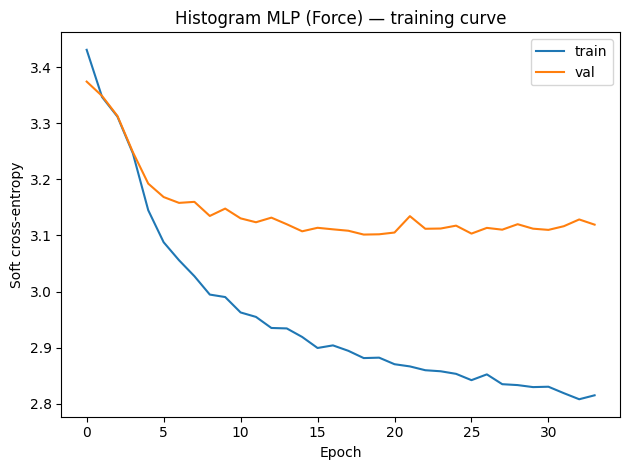

In [29]:
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('Soft cross-entropy')
plt.title('Histogram MLP (Force) — training curve')
plt.legend(); plt.tight_layout(); plt.show()

## 7. Extract penultimate-layer embeddings for the 54 test animations

In [30]:
model.eval()
embeddings_test = model.get_embedding(X_test).numpy()   # (54, 64)
print(f'Test embeddings: {embeddings_test.shape}')

Test embeddings: (54, 64)


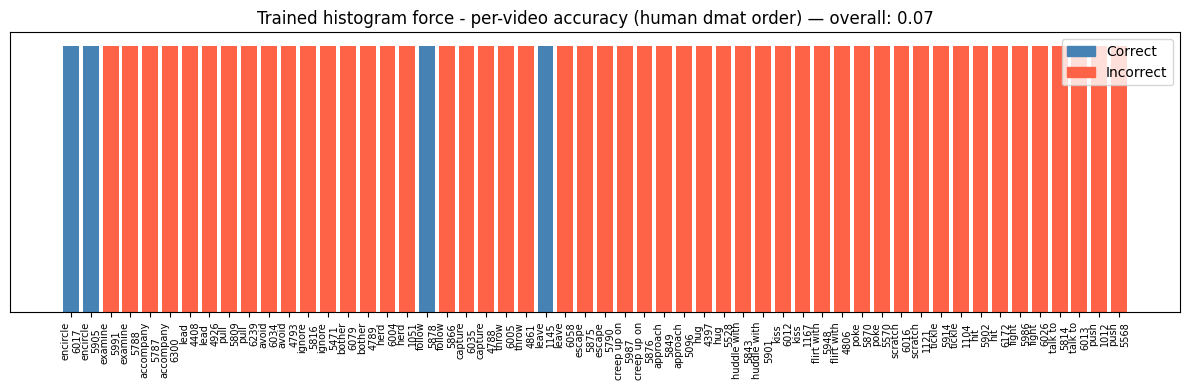


By category:
  encircle        2/2
  examine         0/2
  accompany       0/2
  lead            0/2
  pull            0/2
  avoid           0/2
  ignore          0/2
  bother          0/2
  herd            0/2
  follow          1/2
  capture         0/2
  throw           0/2
  leave           1/2
  escape          0/2
  creep up on     0/2
  approach        0/2
  hug             0/2
  huddle with     0/2
  kiss            0/2
  flirt with      0/2
  poke            0/2
  scratch         0/2
  tickle          0/2
  hit             0/2
  fight           0/2
  talk to         0/2
  push            0/2


In [31]:
# Per-video accuracy ordered by human dmat label order
idx2label = {i: l for l, i in label2idx.items()}

# Reorder test_ids to match human dmat order
human_df  = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids = [int(x.split('_')[0]) for x in human_df.index]
human_labels = [x.split('_')[1] for x in human_df.index]

model.eval()
with torch.no_grad():
    # Get predictions in human dmat order
    reorder_idx = [test_ids.index(i) for i in human_ids]
    X_test_ordered = X_test[reorder_idx]
    logits, _ = model(X_test_ordered)
    pred_idx  = logits.argmax(dim=-1)

true_idx  = torch.tensor([label2idx[id_label_map[i]] for i in human_ids])
correct   = (pred_idx == true_idx).numpy()

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue' if c else 'tomato' for c in correct]
ax.bar(range(len(human_ids)), np.ones(len(human_ids)), color=colors, width=0.8)
ax.set_xticks(range(len(human_ids)))
ax.set_xticklabels(
    [f'{l}\n{i}' for l, i in zip(human_labels, human_ids)],
    rotation=90, fontsize=7
)
ax.set_yticks([])
ax.set_title(f'Trained histogram force - per-video accuracy (human dmat order) — overall: {correct.mean():.2f}')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Correct'),
                   Patch(color='tomato',    label='Incorrect')],
          loc='upper right')
plt.tight_layout()
plt.show()

# Print summary per category
print('\nBy category:')
seen = {}
for i, (vid_id, lbl, c) in enumerate(zip(human_ids, human_labels, correct)):
    seen.setdefault(lbl, []).append(c)
for lbl, results in seen.items():
    print(f'  {lbl:<15} {sum(results)}/{len(results)}')

In [32]:
# Test accuracy — ground truth = argmax of human response distribution
model.eval()
with torch.no_grad():
    logits, _ = model(X_test)
    pred_idx  = logits.argmax(dim=-1)

# Ground truth: most frequent human response label (argmax of soft distribution)
true_idx = torch.tensor([
    np.argmax(soft_label_map[vid_id]) for vid_id in test_ids
])

accuracy = (pred_idx == true_idx).float().mean().item()
print(f'Test accuracy: {accuracy:.2f}')

Test accuracy: 0.13


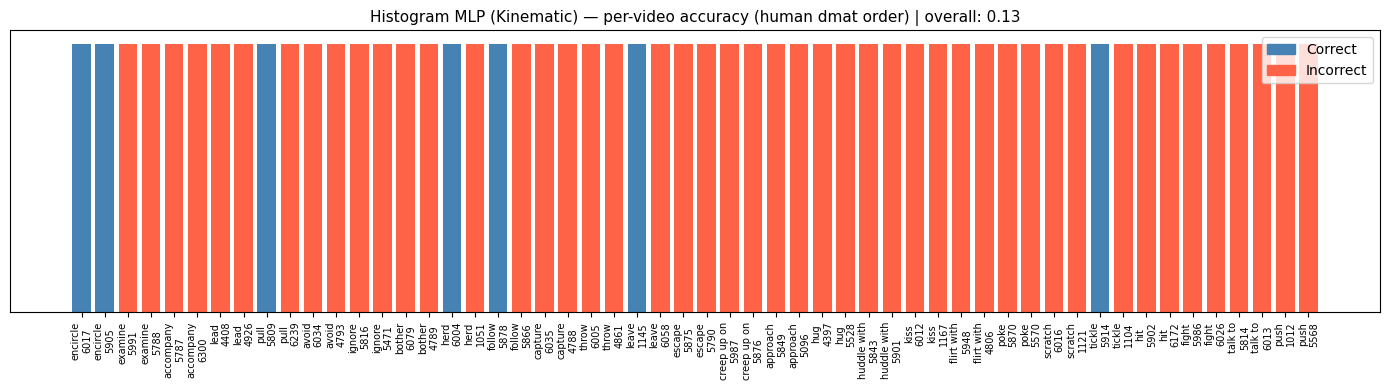


By category:
  accompany       0/2
  approach        0/2
  avoid           0/2
  bother          0/2
  capture         0/2
  creep up on     0/2
  encircle        2/2
  escape          0/2
  examine         0/2
  fight           0/2
  flirt with      0/2
  follow          1/2
  herd            1/2
  hit             0/2
  huddle with     0/2
  hug             0/2
  ignore          0/2
  kiss            0/2
  lead            0/2
  leave           1/2
  poke            0/2
  pull            1/2
  push            0/2
  scratch         0/2
  talk to         0/2
  throw           0/2
  tickle          1/2


In [33]:
# Per-video accuracy in human dmat order
idx2label = {i: l for l, i in label2idx.items()}

# Reorder test to human dmat order
human_df       = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids      = [int(x.split('_')[0]) for x in human_df.index]
human_labels   = [x.split('_')[1]      for x in human_df.index]

model.eval()
with torch.no_grad():
    reorder_idx    = [test_ids.index(i) for i in human_ids]
    X_test_ordered = X_test[reorder_idx]
    logits, _      = model(X_test_ordered)
    pred_idx       = logits.argmax(dim=-1)

true_idx = torch.tensor([
    np.argmax(soft_label_map[i]) for i in human_ids
])
correct = (pred_idx == true_idx).numpy()

# ── Bar plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if c else 'tomato' for c in correct]
ax.bar(range(len(human_ids)), np.ones(len(human_ids)), color=colors, width=0.8)
ax.set_xticks(range(len(human_ids)))
ax.set_xticklabels(
    [f'{lbl}\n{vid}' for lbl, vid in zip(human_labels, human_ids)],
    rotation=90, fontsize=7
)
ax.set_yticks([])
ax.set_title(
    f'Histogram MLP (Kinematic) — per-video accuracy (human dmat order) | overall: {correct.mean():.2f}',
    fontsize=11
)
ax.legend(handles=[
    plt.matplotlib.patches.Patch(color='steelblue', label='Correct'),
    plt.matplotlib.patches.Patch(color='tomato',    label='Incorrect')
], loc='upper right')
plt.tight_layout()
plt.show()

# ── Per-category summary ────────────────────────────────────────────────────
print('\nBy category:')
from collections import defaultdict
cat_results = defaultdict(list)
for lbl, c in zip(human_labels, correct):
    cat_results[lbl].append(c)
for lbl, vals in sorted(cat_results.items()):
    print(f'  {lbl:<15} {sum(vals)}/{len(vals)}')

## 8. Compute cosine distance matrix (54 × 54)

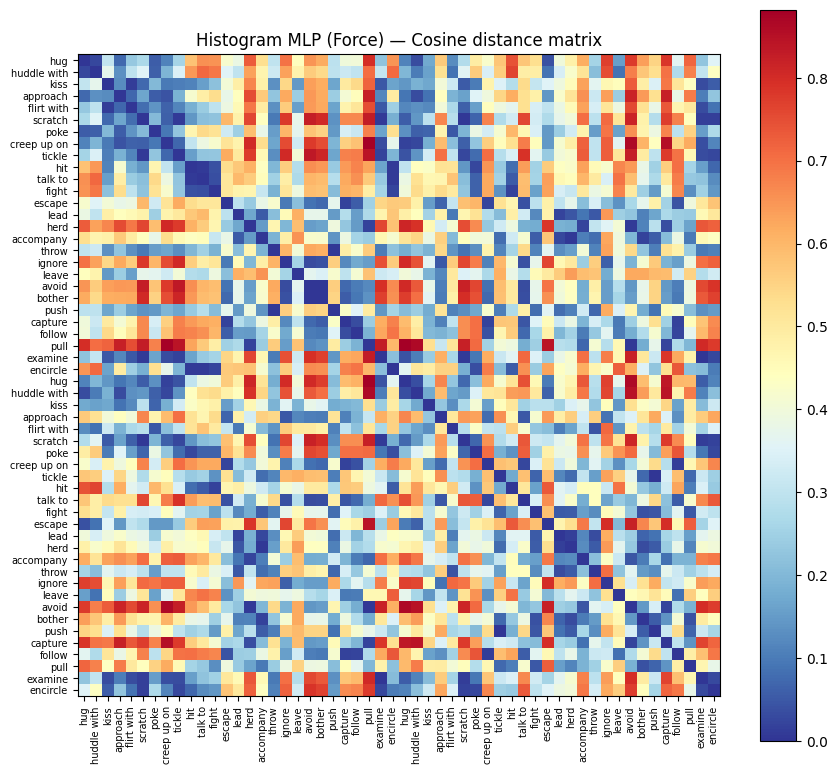

In [34]:
n_test = len(test_ids)
dist_matrix = np.zeros((n_test, n_test))
for i in range(n_test):
    for j in range(n_test):
        if i != j:
            dist_matrix[i, j] = cosine(embeddings_test[i], embeddings_test[j])

test_labels = [id_label_map.get(i, str(i)) for i in test_ids]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(dist_matrix, cmap='RdYlBu_r')
plt.colorbar(im)
ax.set_xticks(range(n_test)); ax.set_xticklabels(test_labels, rotation=90, fontsize=7)
ax.set_yticks(range(n_test)); ax.set_yticklabels(test_labels, fontsize=7)
ax.set_title('Histogram MLP (Force) — Cosine distance matrix')
plt.tight_layout(); plt.show()

## 9. Evaluate: Spearman correlation with human dissimilarity

Reorders model dist_matrix to match the human matrix's canonical ID order.

In [35]:
# Load human dissimilarity matrix (tab-separated, ID_label index)
human_df  = pd.read_csv(HUMAN_DMAT, sep='\t', index_col=0)
human_ids = [int(x.split('_')[0]) for x in human_df.index]  # canonical order

# Reorder model dist_matrix to match human matrix order
model_id_to_idx     = {vid_id: i for i, vid_id in enumerate(test_ids)}
reorder_idx         = [model_id_to_idx[i] for i in human_ids]
dist_matrix_ordered = dist_matrix[np.ix_(reorder_idx, reorder_idx)]

# Replace diagonal NaN with 0
human_mat = human_df.values.copy()
np.fill_diagonal(human_mat, 0)

# Spearman correlation on upper triangle
triu_idx = np.triu_indices(n_test, k=1)
rho, pval = spearmanr(human_mat[triu_idx], dist_matrix_ordered[triu_idx])
print(f'Spearman ρ = {rho:.3f}  (p = {pval:.3e})')
print('Reference — paper values: Histogram force ρ=.381, LSTM force ρ=.516')

Spearman ρ = 0.524  (p = 6.176e-102)
Reference — paper values: Histogram force ρ=.381, LSTM force ρ=.516


## 10. Save outputs

In [36]:
# Save in human-matrix order to match other distance matrices
if onehot:
    pd.DataFrame(dist_matrix_ordered).to_csv(f'{OUT_DIR}/histogram_mlp_onehot_force_dist.csv', index=False, header=False)
    np.save('./results/histogram_mlp_onehot_force_embeddings.npy', embeddings_test)
    pd.DataFrame({'ID': human_ids,
                'label': [id_label_map.get(i, str(i)) for i in human_ids]}).to_csv(
        './results/histogram_mlp_onehot_force_test_order.csv', index=False
    )
    torch.save(model.state_dict(), './results/histogram_mlp_onehot_force_weights.pt')
    print('Saved: dist matrix (human order), embeddings, test order, model weights')
else:
    pd.DataFrame(dist_matrix_ordered).to_csv(
        f'{OUT_DIR}/histogram_mlp_force_dist.csv', index=False, header=False
    )
    np.save('./results/histogram_mlp_force_embeddings.npy', embeddings_test)
    pd.DataFrame({'ID': human_ids,
                'label': [id_label_map.get(i, str(i)) for i in human_ids]}).to_csv(
        './results/histogram_mlp_force_test_order.csv', index=False
    )
    torch.save(model.state_dict(), './results/histogram_mlp_force_weights.pt')
    print('Saved: dist matrix (human order), embeddings, test order, model weights')

Saved: dist matrix (human order), embeddings, test order, model weights
